In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from ddeint import ddeint


# ----------------------------
# Hill function and derivative
# ----------------------------

def H(P, K, n):
    return P**n / (K**n + P**n)


def Hprime(P, K, n):
    return n * K**n * P**(n - 1) / (K**n + P**n)**2


# ----------------------------
# Steady state
# ----------------------------

def steady_state(ks, kd, K, n):

    def f(P):
        return ks - kd * P * (1 + H(P, K, n))

    lo = 0.0
    hi = max(10 * K, 10 * ks / kd + 10)

    while f(hi) > 0:
        hi *= 2

    return brentq(f, lo, hi)


# ----------------------------
# Linear stability coefficients
# ----------------------------

def linear_coefficients(Pstar, kd, K, n):
    a = -kd * (1 + H(Pstar, K, n))
    b = -kd * Pstar * Hprime(Pstar, K, n)
    return a, b


# ----------------------------
# Hopf condition (linear theory)
# ----------------------------

def critical_delay(a, b):
    if abs(b) <= abs(a):
        return None, None

    omega = np.sqrt(b**2 - a**2)
    tau_c = np.arccos(-a / b) / omega

    return tau_c, omega


# ----------------------------
# DDE simulation (ddeint)
# ----------------------------

def simulate_ddeint(ks, kd, K, n, tau, T=300, dt=0.05, perturb=0.05):

    Pstar = steady_state(ks, kd, K, n)

    # history (constant past + small perturbation)
    def history(t):
        return Pstar * (1 + perturb)

    # DDE system
    def model(P, t):
        P_tau = P(t - tau)
        feedback = P_tau**n / (K**n + P_tau**n)

        return ks - kd * P(t) - kd * P(t) * feedback

    times = np.arange(0, T + dt, dt)
    sol = ddeint(model, history, times)

    return times, sol.flatten(), Pstar


# ----------------------------
# Time series near Hopf
# ----------------------------

def plot_time_series_near_hopf(ks, kd, K, n):

    Pstar = steady_state(ks, kd, K, n)
    a, b = linear_coefficients(Pstar, kd, K, n)
    tau_c, omega = critical_delay(a, b)

    print(f"P* = {Pstar:.4f}")
    print(f"a = {a:.4f}, b = {b:.4f}")

    if tau_c is None:
        print("No Hopf predicted (|b| <= |a|).")
        return

    print(f"tau_c = {tau_c:.4f}")
    print(f"omega = {omega:.4f}")

    tau_values = [0.7 * tau_c, tau_c, 1.3 * tau_c]
    labels = [r"$\tau < \tau_c$", r"$\tau = \tau_c$", r"$\tau > \tau_c$"]

    for tau, label in zip(tau_values, labels):

        t, P, Pstar = simulate_ddeint(ks, kd, K, n, tau, T=2000)

        plt.figure(figsize=(8, 4))
        plt.plot(t, P, label="P(t)")
        plt.axhline(Pstar, linestyle="--", label="P*")

        plt.title("concentration Plk4 in time"f"{label}, tau = {tau:.3f}", fontsize = 12)
        plt.xlabel("time", fontsize = 12)
        plt.ylabel("P(t)", fontsize = 12)
        
        plt.xticks(fontsize=12)
        plt.yticks(fontsize=12)
        
        plt.legend()
        plt.tight_layout()
        plt.show()

        
def plot_time_series_near_hopf_short(ks, kd, K, n):

    Pstar = steady_state(ks, kd, K, n)
    a, b = linear_coefficients(Pstar, kd, K, n)
    tau_c, omega = critical_delay(a, b)

    print(f"P* = {Pstar:.4f}")
    print(f"a = {a:.4f}, b = {b:.4f}")

    if tau_c is None:
        print("No Hopf predicted (|b| <= |a|).")
        return

    print(f"tau_c = {tau_c:.4f}")
    print(f"omega = {omega:.4f}")

    tau_values = [0.5 * tau_c, tau_c, 1.3 * tau_c]
    labels = [r"$\tau < \tau_c$", r"$\tau = \tau_c$", r"$\tau > \tau_c$"]

    for tau, label in zip(tau_values, labels):

        t, P, Pstar = simulate_ddeint(ks, kd, K, n, tau, T=75)

        plt.figure(figsize=(8, 4))
        plt.plot(t, P, label="P(t)")
        plt.axhline(Pstar, linestyle="--", label="P*")

        plt.title("concentration Plk4 in time"f"{label}, tau = {tau:.3f}", fontsize = 12)
        plt.xlabel("time", fontsize = 12)
        plt.ylabel("P(t)", fontsize = 12)
        
        plt.xticks(fontsize=12)
        plt.yticks(fontsize=12)
        
        plt.legend()
        plt.tight_layout()
        plt.show()
        
# ----------------------------
# Bifurcation diagram vs tau
# ----------------------------

def bifurcation_diagram_tau(ks, kd, K, n,
                            tau_min=0.0,
                            tau_max=12.0,
                            num_tau=50,
                            T=10000,
                            dt=0.05,
                            transient_fraction=0.9):

    taus = np.linspace(tau_min, tau_max, num_tau)

    Pstar = steady_state(ks, kd, K, n)

    a, b = linear_coefficients(Pstar, kd, K, n)
    tau_c, omega = critical_delay(a, b)

    max_vals = []
    min_vals = []

    for tau in taus:

        print(f"tau = {tau:.3f}")

        t, P, _ = simulate_ddeint(ks, kd, K, n, tau, T=T)

        cut = int(len(P) * transient_fraction)
        P_ss = P[cut:]

        max_vals.append(np.max(P_ss))
        min_vals.append(np.min(P_ss))

    plt.figure(figsize=(8, 5))
    plt.plot(taus, max_vals, ".", label="max long-time")
    plt.plot(taus, min_vals, ".", label="min long-time")
    plt.axhline(Pstar, linestyle="--", label="P*")

    plt.xlabel("delay tau", fontsize = 12)
    plt.ylabel("P(t)", fontsize = 12)
    plt.title("Bifurcation diagram Plk4 oscillator", fontsize = 12)
    
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    
    if tau_c is not None:
        plt.axvline(
            tau_c,
            color='red',
            linestyle='--',
            linewidth=2,
            label=r'$\tau_c$'
        )
    
    plt.legend()
    plt.tight_layout()
    plt.show()


# ----------------------------
# Phase portrait
# ----------------------------

def plot_delay_phase_portrait(ks, kd, K, n, tau, T=300, dt=0.05, perturb=0.05):

    t, P, Pstar = simulate_ddeint(ks, kd, K, n, tau, T, dt, perturb)

    delay_steps = int(tau / dt)

    if delay_steps < 1:
        raise ValueError("tau too small relative to dt")

    P_now = P[delay_steps:]
    P_delay = P[:-delay_steps]

    plt.figure(figsize=(6, 6))

    # trajectory
    plt.plot(P_delay, P_now, linewidth=1.5)

    # start point
    plt.scatter(P_delay[0], P_now[0],
                color='green', s=80, label='start')

    # end point
    plt.scatter(P_delay[-1], P_now[-1],
                color='red', s=80, label='end')

    # steady state
    plt.scatter([Pstar], [Pstar],
                marker='x', s=120, color='black',
                label='P*')

    plt.xlabel(r"$P(t-\tau)$", fontsize=14)
    plt.ylabel(r"$P(t)$", fontsize=14)

    plt.title(f"Phase portrait tau={tau:.3f}", fontsize=16)

    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)

    plt.legend(fontsize=12)

    plt.tight_layout()
    plt.show()



P* = 0.8372
a = -1.1944, b = -1.2531
tau_c = 7.4831
omega = 0.3788


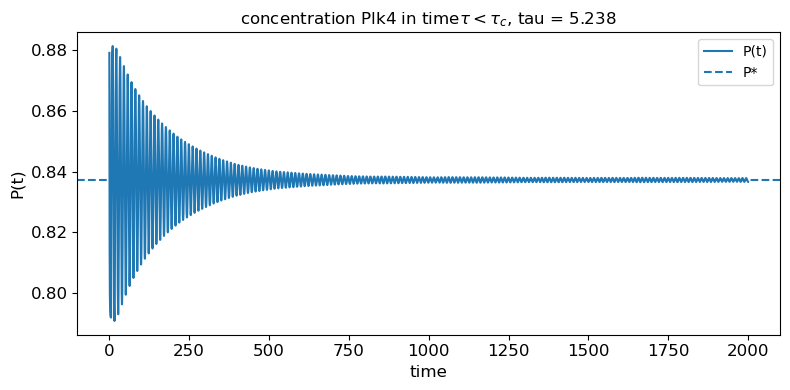

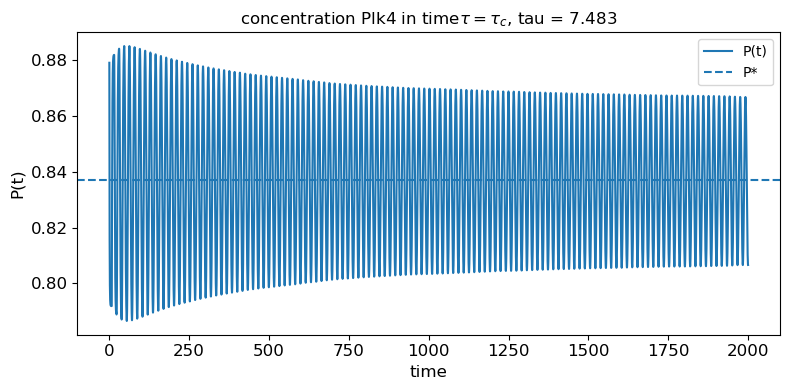

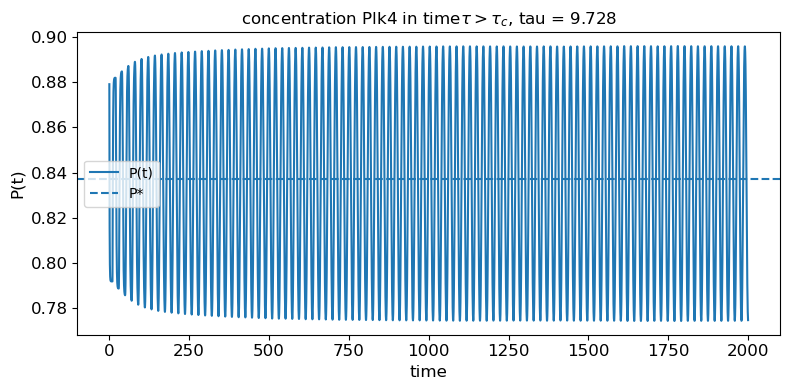

In [3]:
# ----------------------------
# RUN ANALYSIS
# ----------------------------

ks = 1.0
kd = 1.0
K = 1.0
n = 8

plot_time_series_near_hopf(ks, kd, K, n)
#plot_time_series_near_hopf_short(ks, kd, K, n)

#bifurcation_diagram_tau(ks, kd, K, n,
#                        tau_min=0.0,
#                        tau_max=10.0,
#                        num_tau=40,
#                        T=2000)

Pstar = steady_state(ks, kd, K, n)
a, b = linear_coefficients(Pstar, kd, K, n)
tau_c, _ = critical_delay(a, b)

#if tau_c is not None:
 #   plot_delay_phase_portrait(ks, kd, K, n, 0.7 * tau_c)
  #  plot_delay_phase_portrait(ks, kd, K, n, 1.3 * tau_c)


In [19]:
# ----------------------------
# Amplitude vs time
# ----------------------------

def plot_amplitude_time_series(ks, kd, K, n,
                               tau_factor=1.01,
                               T=10000,
                               dt=0.05):

    # Compute steady state and Hopf point
    Pstar = steady_state(ks, kd, K, n)
    a, b = linear_coefficients(Pstar, kd, K, n)
    tau_c, omega = critical_delay(a, b)

    if tau_c is None:
        print("No Hopf bifurcation predicted.")
        return

    # Choose tau relative to Hopf delay
    tau = tau_factor * tau_c

    # Simulate
    t, P, _ = simulate_ddeint(ks, kd, K, n,
                              tau,
                              T=T,
                              dt=dt)

    # Amplitude relative to steady state
    amplitude = np.abs(P - Pstar)

    # Plot
    plt.figure(figsize=(8,4))

    plt.plot(t, amplitude, linewidth=2)

    plt.xlabel("time", fontsize = 12)
    plt.ylabel("Amplitude |P(t) - P*|", fontsize = 12)
    
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)

    plt.title(f"Oscillation amplitude vs time\n"
              f"tau = {tau:.3f}", fontsize = 12)

    plt.tight_layout()
    plt.show()

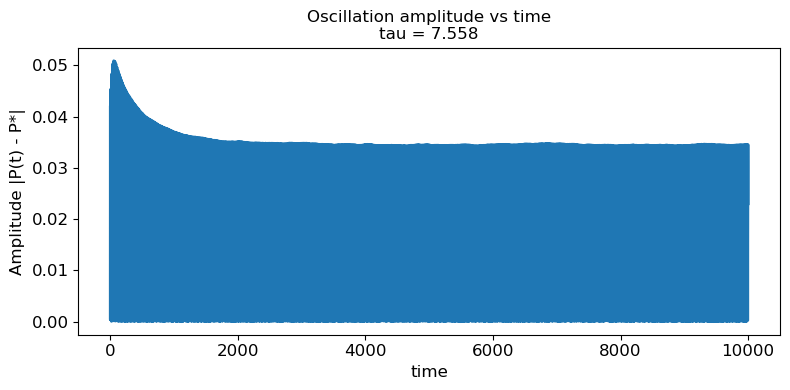

In [20]:
plot_amplitude_time_series(ks, kd, K, n)

In [21]:
from scipy.signal import find_peaks
from scipy.stats import linregress

# ----------------------------
# Log-scale peak growth fit
# ----------------------------

def plot_log_peak_fit(ks, kd, K, n,
                      tau_factor=1,
                      T=500,
                      dt=0.05):

    # Steady state and Hopf delay
    Pstar = steady_state(ks, kd, K, n)
    a, b = linear_coefficients(Pstar, kd, K, n)
    tau_c, _ = critical_delay(a, b)

    if tau_c is None:
        print("No Hopf bifurcation predicted.")
        return

    tau = tau_factor * tau_c

    # Simulate system
    t, P, _ = simulate_ddeint(
        ks, kd, K, n,
        tau,
        T=T,
        dt=dt
    )

    # Detect peaks
    peaks, _ = find_peaks(P)

    peak_times = t[peaks]
    peak_values = P[peaks]

    # Amplitude above steady state
    amplitudes = peak_values - Pstar

    # Keep only positive amplitudes
    mask = amplitudes > 1e-8
    peak_times = peak_times[mask]
    amplitudes = amplitudes[mask]

    # Log transform
    log_amp = np.log(amplitudes)

    # Linear regression
    slope, intercept, r_value, _, _ = linregress(
        peak_times,
        log_amp
    )

    # Fitted line
    fit_line = intercept + slope * peak_times

    # ----------------------------
    # Plot
    # ----------------------------

    plt.figure(figsize=(8,4))

    plt.plot(
        peak_times,
        log_amp,
        'ro',
        label='log(peaks)'
    )

    plt.plot(
        peak_times,
        fit_line,
        linewidth=2,
        label=fr'Linear fit: slope = {slope:.4f}'
    )

    plt.xlabel("time", fontsize = 12)
    plt.ylabel(r"$\log(A)$", fontsize = 12)
    
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)

    plt.title("Logarithmic peak amplitude evolution for the Plk4 oscillator", fontsize = 12)

    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"Exponential growth rate λ = {slope:.6f}")
    print(f"R² = {r_value**2:.6f}")

    return slope

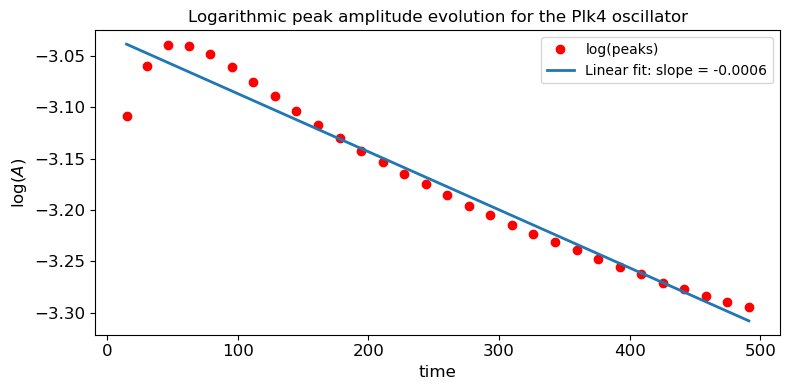

Exponential growth rate λ = -0.000566
R² = 0.957525


-0.0005658951908076898

In [22]:
plot_log_peak_fit(ks, kd, K, n)

In [39]:
from scipy.signal import find_peaks


def plot_period_amplitude(
    kd,
    K,
    n,
    tau,
    ks_min=0.5,
    ks_max=3.5,
    num=60,
    T=500,
    dt=0.05,
    transient_fraction=0.5,
    prominence=0.01
):
    """
    Oscillation period and amplitude versus synthesis rate ks.
    """

    ks_values = np.linspace(ks_min, ks_max, num)

    periods = []
    amplitudes = []

    for ks_val in ks_values:

        print(f"ks = {ks_val:.3f}")

        # Use your existing DDE simulator
        t, P, _ = simulate_ddeint(
            ks_val,
            kd,
            K,
            n,
            tau,
            T=T,
            dt=dt
        )

        # Remove transient
        cut = int(len(P) * transient_fraction)

        P_ss = P[cut:]
        t_ss = t[cut:]

        # Find peaks/troughs
        peaks, _ = find_peaks(P_ss, prominence=prominence)
        troughs, _ = find_peaks(-P_ss, prominence=prominence)

        # Need at least 2 peaks to define a period
        if len(peaks) >= 2:

            peak_times = t_ss[peaks]

            # Oscillation period
            period = np.mean(np.diff(peak_times))

            # Oscillation amplitude
            if len(troughs) >= 1:

                amplitude = (
                    np.mean(P_ss[peaks])
                    - np.mean(P_ss[troughs])
                )/2

            else:
                amplitude = np.nan

            periods.append(period)
            amplitudes.append(amplitude)

        else:
            periods.append(np.nan)
            amplitudes.append(np.nan)

    periods = np.array(periods)
    amplitudes = np.array(amplitudes)

    osc_mask = np.isfinite(periods)

    # ----------------------------
    # Plotting
    # ----------------------------

    fig, axes = plt.subplots(
        1, 2,
        figsize=(11, 4),
        constrained_layout=True
    )

    fig.suptitle(
        r'Oscillation properties vs synthesis rate $k_s$'
    )

    # ----------------------------
    # Period
    # ----------------------------

    axes[0].plot(
        ks_values[osc_mask],
        periods[osc_mask],
        'ko-',
        ms=4,
        lw=1.5
    )

    axes[0].set_xlabel(r'$k_s$', fontsize = 12)
    axes[0].set_ylabel('Period', fontsize = 12)

    axes[0].set_title('Oscillation period', fontsize = 12)
    axes[0].grid(alpha=0.3)

    # ----------------------------
    # Amplitude
    # ----------------------------

    axes[1].plot(
        ks_values[osc_mask],
        amplitudes[osc_mask],
        'ko-',
        ms=4,
        lw=1.5
    )

    axes[1].set_xlabel(r'$k_s$', fontsize = 12)
    axes[1].set_ylabel('Amplitude', fontsize = 12)
    
    axes[1].set_title('Oscillation amplitude', fontsize = 12)
    axes[1].grid(alpha=0.3)

    axes[0].tick_params(axis='both', labelsize=12)
    axes[1].tick_params(axis='both', labelsize=12)
    
    plt.show()

    return fig

ks = 0.500
ks = 0.551
ks = 0.602
ks = 0.653
ks = 0.703
ks = 0.754
ks = 0.805
ks = 0.856
ks = 0.907
ks = 0.958
ks = 1.008
ks = 1.059
ks = 1.110
ks = 1.161
ks = 1.212
ks = 1.263
ks = 1.314
ks = 1.364
ks = 1.415
ks = 1.466
ks = 1.517
ks = 1.568
ks = 1.619
ks = 1.669
ks = 1.720
ks = 1.771
ks = 1.822
ks = 1.873
ks = 1.924
ks = 1.975
ks = 2.025
ks = 2.076
ks = 2.127
ks = 2.178
ks = 2.229
ks = 2.280
ks = 2.331
ks = 2.381
ks = 2.432
ks = 2.483
ks = 2.534
ks = 2.585
ks = 2.636
ks = 2.686
ks = 2.737
ks = 2.788
ks = 2.839
ks = 2.890
ks = 2.941
ks = 2.992
ks = 3.042
ks = 3.093
ks = 3.144
ks = 3.195
ks = 3.246
ks = 3.297
ks = 3.347
ks = 3.398
ks = 3.449
ks = 3.500


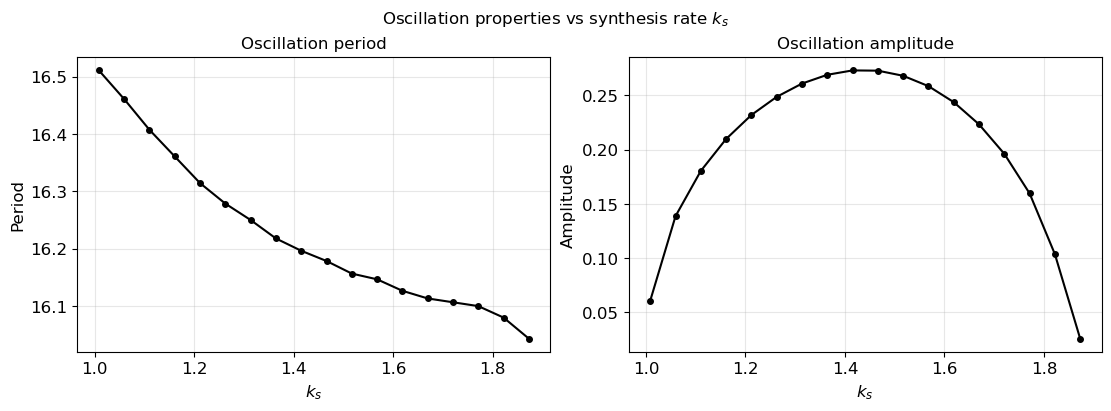

P* = 0.8372
a = -1.1944, b = -1.2531
tau_c = 7.4831
omega = 0.3788


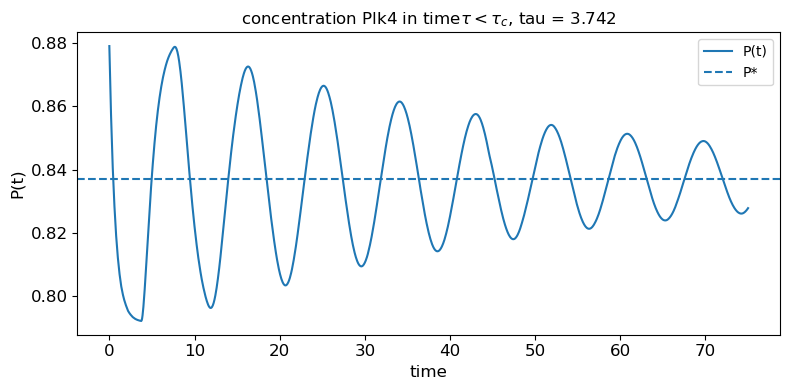

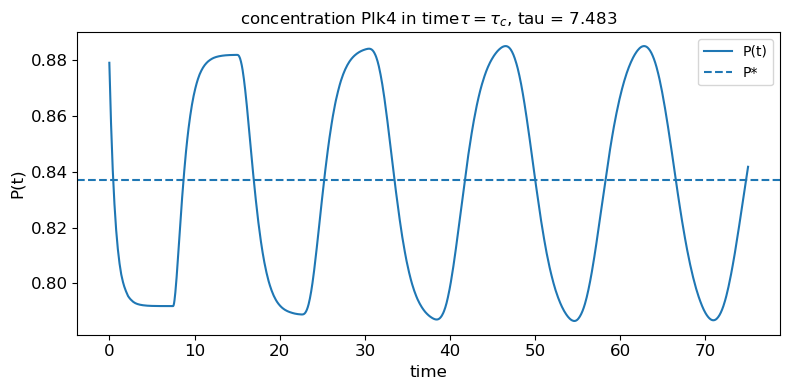

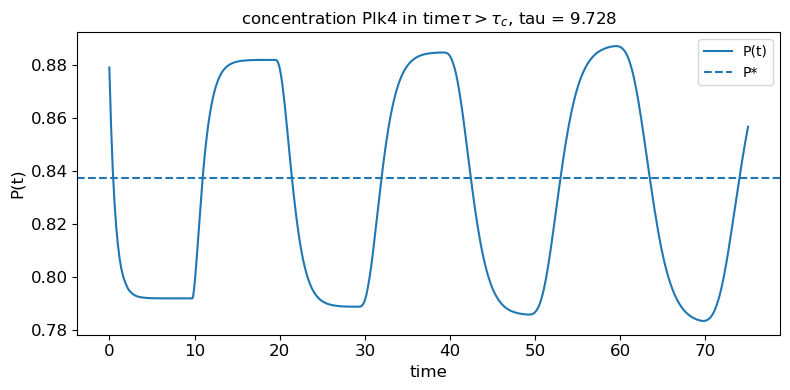

In [40]:
#variable ks

ks = 1.0
kd = 1.0
K = 1.0
n = 8
tau = 7.5


plot_period_amplitude(kd, K, n, tau)

plot_time_series_near_hopf_short(ks, kd, K, n)

In [41]:
from scipy.signal import find_peaks


def plot_period_amplitude_vs_kd(
    ks,
    K,
    n,
    tau,
    kd_min=0.1,
    kd_max=1.5,
    num=60,
    T=500,
    dt=0.05,
    transient_fraction=0.5,
    prominence=0.01
):
    """
    Oscillation period and amplitude versus degradation rate kd.
    """

    kd_values = np.linspace(kd_min, kd_max, num)

    periods = []
    amplitudes = []

    for kd_val in kd_values:

        print(f"kd = {kd_val:.3f}")

        # Run simulation
        t, P, _ = simulate_ddeint(
            ks,
            kd_val,
            K,
            n,
            tau,
            T=T,
            dt=dt
        )

        # Remove transient
        cut = int(len(P) * transient_fraction)

        P_ss = P[cut:]
        t_ss = t[cut:]

        # Detect peaks and troughs
        peaks, _ = find_peaks(
            P_ss,
            prominence=prominence
        )

        troughs, _ = find_peaks(
            -P_ss,
            prominence=prominence
        )

        # Need at least 2 peaks
        if len(peaks) >= 2:

            peak_times = t_ss[peaks]

            # Oscillation period
            period = np.mean(np.diff(peak_times))

            # Oscillation amplitude
            if len(troughs) >= 1:

                amplitude = (
                    np.mean(P_ss[peaks])
                    - np.mean(P_ss[troughs])
                )/2

            else:
                amplitude = np.nan

            periods.append(period)
            amplitudes.append(amplitude)

        else:
            periods.append(np.nan)
            amplitudes.append(np.nan)

    periods = np.array(periods)
    amplitudes = np.array(amplitudes)

    # ----------------------------
    # Plotting
    # ----------------------------

    fig, axes = plt.subplots(
        1, 2,
        figsize=(11, 4),
        constrained_layout=True
    )

    fig.suptitle(
        r'Oscillation properties vs degradation rate $k_d$'
    )

    # ----------------------------
    # Period plot
    # ----------------------------

    axes[0].plot(
        kd_values,
        periods,
        'ko-',
        ms=4,
        lw=1.5
    )

    axes[0].set_xlabel(r'$k_d$', fontsize = 12)
    axes[0].set_ylabel('Period', fontsize = 12)

    axes[0].set_title('Oscillation period', fontsize = 12)
    axes[0].grid(alpha=0.3)

    # ----------------------------
    # Amplitude plot
    # ----------------------------

    axes[1].plot(
        kd_values,
        amplitudes,
        'ko-',
        ms=4,
        lw=1.5
    )

    axes[1].set_xlabel(r'$k_d$', fontsize = 12)
    axes[1].set_ylabel('Amplitude', fontsize = 12)
    
    axes[1].set_title('Oscillation amplitude', fontsize = 12)
    axes[1].grid(alpha=0.3)
    
    axes[0].tick_params(axis='both', labelsize=12)
    axes[1].tick_params(axis='both', labelsize=12)

    plt.show()

    return fig

kd = 0.100
kd = 0.124
kd = 0.147
kd = 0.171
kd = 0.195
kd = 0.219
kd = 0.242
kd = 0.266
kd = 0.290
kd = 0.314
kd = 0.337
kd = 0.361
kd = 0.385
kd = 0.408
kd = 0.432
kd = 0.456
kd = 0.480
kd = 0.503
kd = 0.527
kd = 0.551
kd = 0.575
kd = 0.598
kd = 0.622
kd = 0.646
kd = 0.669
kd = 0.693
kd = 0.717
kd = 0.741
kd = 0.764
kd = 0.788
kd = 0.812
kd = 0.836
kd = 0.859
kd = 0.883
kd = 0.907
kd = 0.931
kd = 0.954
kd = 0.978
kd = 1.002
kd = 1.025
kd = 1.049
kd = 1.073
kd = 1.097
kd = 1.120
kd = 1.144
kd = 1.168
kd = 1.192
kd = 1.215
kd = 1.239
kd = 1.263
kd = 1.286
kd = 1.310
kd = 1.334
kd = 1.358
kd = 1.381
kd = 1.405
kd = 1.429
kd = 1.453
kd = 1.476
kd = 1.500


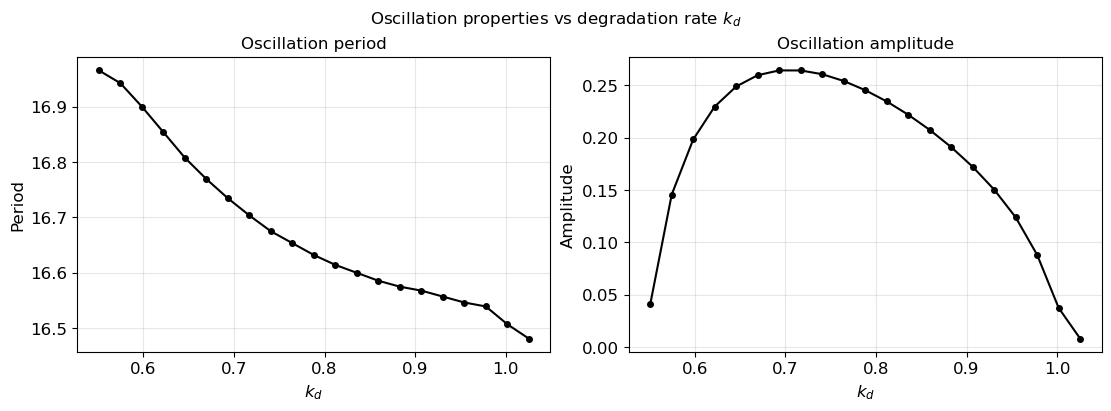

P* = 0.8372
a = -1.1944, b = -1.2531
tau_c = 7.4831
omega = 0.3788


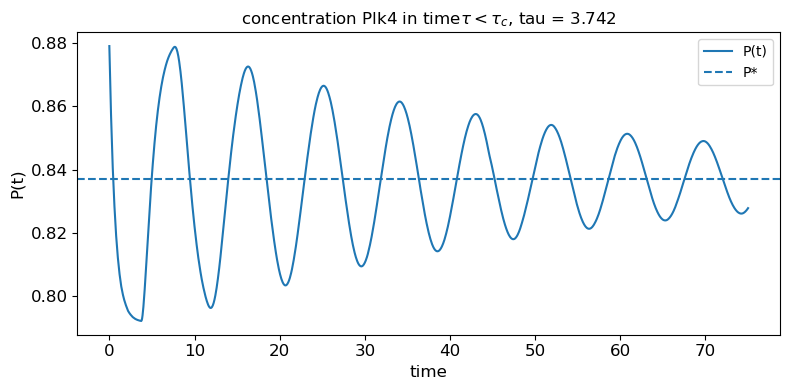

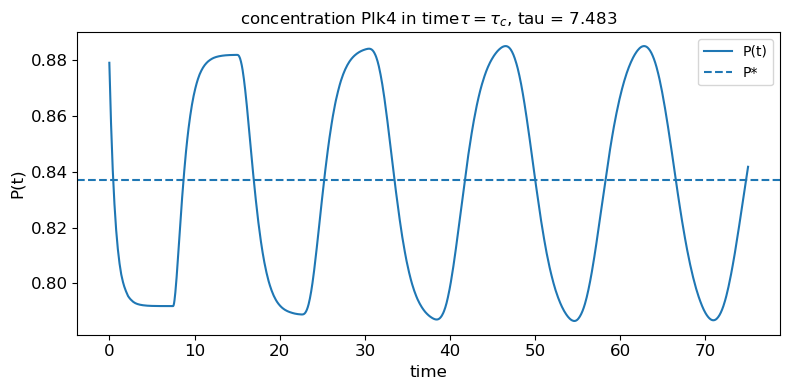

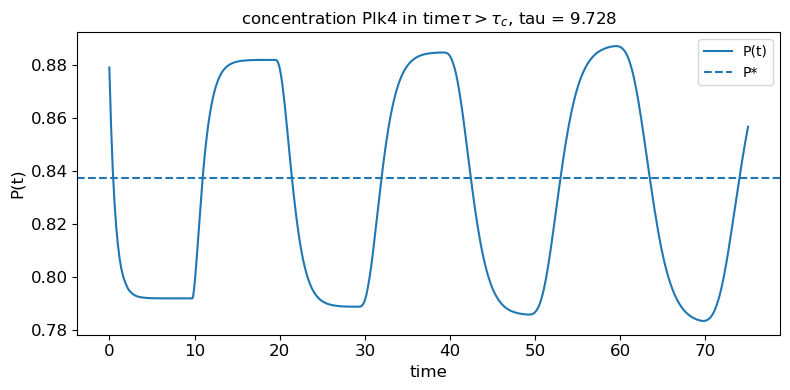

In [42]:
#variable ks

ks = 1
kd = 1
K = 1.0
n = 8
tau = 7.5


plot_period_amplitude_vs_kd(ks, K, n, tau)

plot_time_series_near_hopf_short(ks, kd, K, n)

In [43]:
from scipy.signal import find_peaks


def plot_period_amplitude_vs_tau(
    ks,
    kd,
    K,
    n,
    tau_min=0.0,
    tau_max=30.0,
    num=60,
    T=500,
    dt=0.05,
    transient_fraction=0.5,
    prominence=0.01
):
    """
    Oscillation period and amplitude versus delay tau.
    """

    tau_values = np.linspace(tau_min, tau_max, num)

    periods = []
    amplitudes = []

    for tau_val in tau_values:

        print(f"tau = {tau_val:.3f}")

        # Run simulation
        t, P, _ = simulate_ddeint(
            ks,
            kd,
            K,
            n,
            tau_val,
            T=T,
            dt=dt
        )

        # Remove transient
        cut = int(len(P) * transient_fraction)

        P_ss = P[cut:]
        t_ss = t[cut:]

        # Detect peaks and troughs
        peaks, _ = find_peaks(
            P_ss,
            prominence=prominence
        )

        troughs, _ = find_peaks(
            -P_ss,
            prominence=prominence
        )

        # Need at least 2 peaks
        if len(peaks) >= 2:

            peak_times = t_ss[peaks]

            # Oscillation period
            period = np.mean(np.diff(peak_times))

            # Oscillation amplitude
            if len(troughs) >= 1:

                amplitude = (
                    (np.mean(P_ss[peaks])
                    - np.mean(P_ss[troughs]))/2
                )

            else:
                amplitude = np.nan

            periods.append(period)
            amplitudes.append(amplitude)

        else:
            periods.append(np.nan)
            amplitudes.append(np.nan)

    periods = np.array(periods)
    amplitudes = np.array(amplitudes)

    # ----------------------------
    # Plotting
    # ----------------------------

    fig, axes = plt.subplots(
        1, 2,
        figsize=(11, 4),
        constrained_layout=True
    )

    fig.suptitle(
        r'Oscillation properties vs delay $\tau$'
    )

    # ----------------------------
    # Period plot
    # ----------------------------

    axes[0].plot(
        tau_values,
        periods,
        'ko-',
        ms=4,
        lw=1.5
    )

    axes[0].set_xlabel(r'$\tau$', fontsize = 12)
    axes[0].set_ylabel('Period', fontsize = 12)

    axes[0].set_title('Oscillation period', fontsize = 12)
    axes[0].grid(alpha=0.3)

    # ----------------------------
    # Amplitude plot
    # ----------------------------

    axes[1].plot(
        tau_values,
        amplitudes,
        'ko-',
        ms=4,
        lw=1.5
    )

    axes[1].set_xlabel(r'$\tau$', fontsize = 12)
    axes[1].set_ylabel('Amplitude', fontsize = 12)
    
    axes[1].set_title('Oscillation amplitude', fontsize = 12)
    axes[1].grid(alpha=0.3)
    
    axes[0].tick_params(axis='both', labelsize=12)
    axes[1].tick_params(axis='both', labelsize=12)

    plt.show()

    return fig

tau = 0.000
tau = 0.508
tau = 1.017
tau = 1.525
tau = 2.034
tau = 2.542
tau = 3.051
tau = 3.559
tau = 4.068
tau = 4.576
tau = 5.085
tau = 5.593
tau = 6.102
tau = 6.610
tau = 7.119
tau = 7.627
tau = 8.136
tau = 8.644
tau = 9.153
tau = 9.661
tau = 10.169
tau = 10.678
tau = 11.186
tau = 11.695
tau = 12.203
tau = 12.712
tau = 13.220
tau = 13.729
tau = 14.237
tau = 14.746
tau = 15.254
tau = 15.763
tau = 16.271
tau = 16.780
tau = 17.288
tau = 17.797
tau = 18.305
tau = 18.814
tau = 19.322
tau = 19.831
tau = 20.339
tau = 20.847
tau = 21.356
tau = 21.864
tau = 22.373
tau = 22.881
tau = 23.390
tau = 23.898
tau = 24.407
tau = 24.915
tau = 25.424
tau = 25.932
tau = 26.441
tau = 26.949
tau = 27.458
tau = 27.966
tau = 28.475
tau = 28.983
tau = 29.492
tau = 30.000


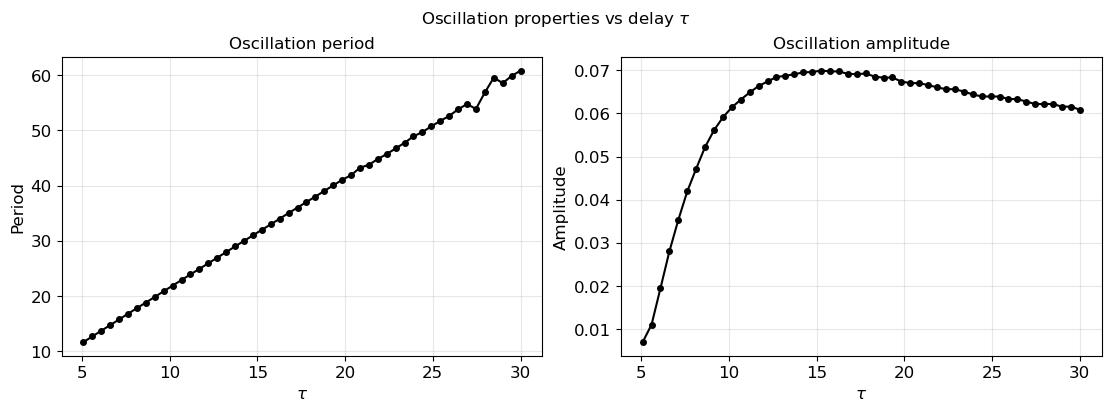

P* = 0.8372
a = -1.1944, b = -1.2531
tau_c = 7.4831
omega = 0.3788


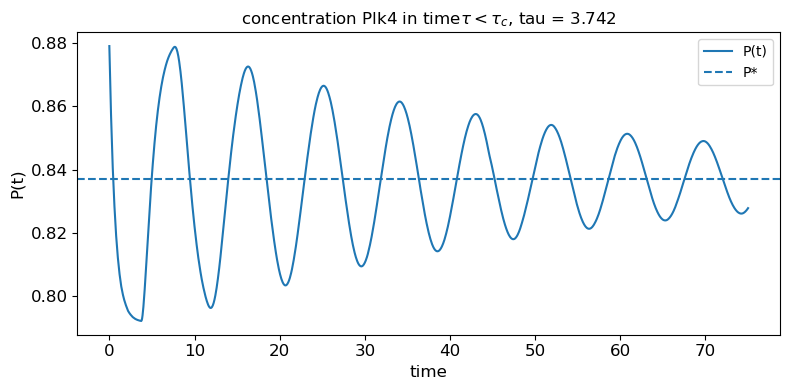

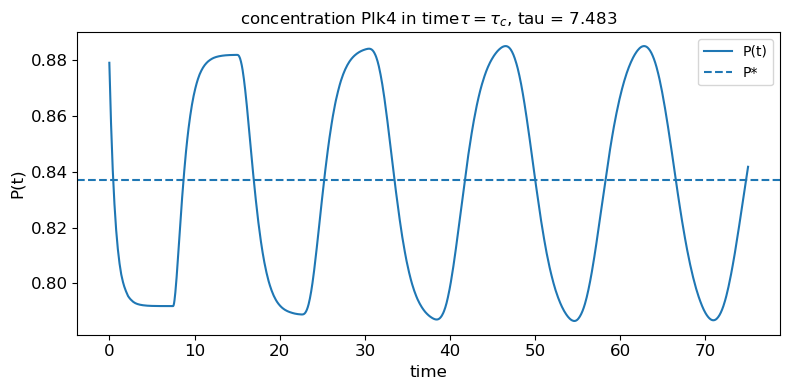

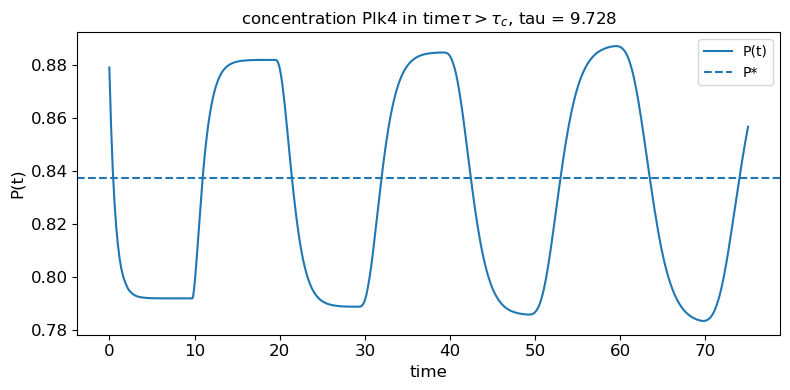

In [44]:
#variable ks

ks = 1
kd = 1.0
K = 1.0
n = 8
tau = 7.5


plot_period_amplitude_vs_tau(ks, kd, K, n)

plot_time_series_near_hopf_short(ks, kd, K, n)